---
<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>CheckPoint05</strong></h2>
<h3 style="text-align: center;"><strong>Random Forest, XGBoost e LightGBM: modelagem, tuning, avaliação e deploy</strong></h3>
<h4 style="text-align: center;"><strong>Versão única</strong></h4>

<style>
.jp-MarkdownOutput, .text_cell_render {
    font-family: "Latin Modern Roman", "CMU Serif", Georgia, "DejaVu Serif", serif;
    font-size: 18px;
    line-height: 1.6;
}
.jp-MarkdownOutput p, .text_cell_render p,
.jp-MarkdownOutput li, .text_cell_render li {
    line-height: 1.6;
}
</style>

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Configuração visual:</strong> o notebook prioriza tipografia serifada para células Markdown. A renderização de CSS pode variar entre Jupyter Notebook, JupyterLab, VS Code e Google Colab; quando uma fonte não estiver disponível, o visualizador utilizará uma alternativa local. O código permanece com fonte monoespaçada do ambiente.
</div>

<br>

---

<br>

## **Identificação dos alunos**

A atividade deve ser realizada em **grupos de no máximo 5 alunos**. Preencha, abaixo, o nome e o RM de cada integrante do grupo. Caso o grupo tenha menos de cinco integrantes, mantenha sem preenchimento os campos não utilizados.


In [1]:
integrantes = {
    "564711": "Pedro Rodrigues Almeida",
    "561732": "Alexandre Martins Lucas",
    "562298": "Vitor Carvalho Alexandre",
    "570133": "Gabriel Barbosa",
}
for rm, nome in integrantes.items():
    print(f"RM {rm} - {nome}")

RM 564711 - Pedro Rodrigues Almeida
RM 561732 - Alexandre Martins Lucas
RM 562298 - Vitor Carvalho Alexandre
RM 570133 - Gabriel Barbosa


<br>

---

<br>

# **CheckPoint05**

## **Objetivos**

- Estruturar um problema real de **classificação** ou **regressão** a partir de uma base de dados escolhida pelo grupo.
- Realizar **data wrangling**, análise exploratória e seleção justificada das variáveis preditoras.
- Implementar e comparar **Random Forest**, **XGBoost** e **LightGBM** sob o mesmo protocolo experimental.
- Ajustar hiperparâmetros com **Grid Search** e **Optuna**, sem utilizar o conjunto de teste durante a busca.
- Selecionar o melhor modelo com base em evidências quantitativas e analisar **overfitting** e **underfitting**.
- Avaliar o modelo final em dados não utilizados no desenvolvimento e construir um teste de consistência das previsões.
- Disponibilizar o projeto em um repositório **GitHub** e uma interface funcional em **Streamlit**.

## **Instruções**

- Leia cada enunciado com atenção.
- Observe a pontuação indicada em cada questão. A atividade vale **10 pontos** no total.
- O grupo deve escolher **um único problema** que possa ser tratado como classificação ou regressão e utilizar a mesma base em toda a atividade.
- A base pode ser pública, institucional autorizada ou coletada pelo grupo. A fonte, a licença ou a forma de obtenção devem ser documentadas.
- O problema deve produzir uma representação tabular de atributos e variável-alvo. Não utilize dados pessoais ou sensíveis sem autorização e justificativa acadêmica adequada.
- Sempre que necessário, registre o raciocínio antes da implementação em Python.
- Quando o item pedir interpretação, responda com base nos resultados obtidos, não apenas com definições genéricas.
- Responda os exercícios nos espaços indicados. Caso seja necessário, adicione células para complementar a resposta.
- Indique de forma organizada a solução dos exercícios.
- Preocupe-se em fazer um código Python limpo, documentado e reprodutível. Esse aspecto será avaliado ao longo de toda a atividade.
- O conjunto de **teste deve permanecer isolado** durante seleção de variáveis, comparação de modelos e tuning. Ele só poderá ser utilizado no Exercício 7.
- O envio da atividade deve incluir o notebook `.ipynb`, o link do repositório GitHub e o link da aplicação Streamlit.
- Cada grupo deverá realizar uma **apresentação oral da solução, com duração máxima de 10 minutos**, sintetizando o problema, as principais decisões metodológicas, a comparação entre os modelos, o modelo final e a demonstração da aplicação.
- Execute o notebook do início ao fim antes do envio. Ele não deve conter erros durante a execução.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Entregáveis obrigatórios:</strong> notebook final, repositório GitHub reproduzível, aplicação Streamlit funcional e **apresentação oral da solução com duração máxima de 10 minutos**. O repositório deve conter, no mínimo, README com instruções de execução, arquivo de dependências, código da aplicação e os arquivos necessários para reproduzir o treinamento ou carregar o modelo final.
</div>

In [2]:
from pathlib import Path
from time import perf_counter
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
from IPython.display import display, Markdown
from sklearn.datasets import load_wine
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, learning_curve, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
    log_loss, confusion_matrix, ConfusionMatrixDisplay, classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
ROOT = Path.cwd()
for folder in ['results', 'figures', 'artifacts']:
    (ROOT / folder).mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.figsize': (9, 5), 'figure.dpi': 110})
def figure(name):
    plt.tight_layout()
    plt.savefig(ROOT / 'figures' / f'{name}.png', dpi=160, bbox_inches='tight')
    plt.show()

<br>

---

<br>

## **Notação utilizada na atividade**

Considere a base de dados como

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n},
$$

em que $\mathbf{x}_i$ representa as variáveis preditoras da observação $i$ e $y_i$ representa a variável-alvo. Ao organizar os dados, utilize a notação

$$
\mathbf{X} \quad \text{para a matriz de atributos},
\qquad
\mathbf{y} \quad \text{para o vetor da variável-alvo}.
$$

A separação deve produzir

$$
\mathcal{D}_{\mathrm{treino}}
\quad \text{e} \quad
\mathcal{D}_{\mathrm{teste}},
$$

sendo $\mathcal{D}_{\mathrm{teste}}$ mantido fora de todo o processo de seleção e tuning. Os três modelos serão indicados por

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

As previsões serão representadas por $\hat{\mathbf{y}}$. Para hiperparâmetros, utilize $\boldsymbol{\theta}$ e registre os melhores valores encontrados por cada estratégia de busca.

<br>

---

<br>

## **Exercícios propostos**

A atividade foi organizada como um fluxo completo de desenvolvimento de um projeto de machine learning. Os sete exercícios devem ser respondidos em sequência, pois as decisões tomadas nas etapas iniciais serão utilizadas nas etapas seguintes.

<br>

---

<br>

### **Exercício 1 — Definição do problema e da base de dados — 1,0 ponto**

Escolha um problema real que possa ser tratado por **Random Forest**, **XGBoost** e **LightGBM**. O problema pode ser de classificação ou regressão.

1. **Contexto e problema — 0,25 ponto.** Descreva o contexto, a pergunta que será respondida e por que uma solução preditiva é adequada.
2. **Variável-alvo — 0,25 ponto.** Defina $y$, informe se o problema é de classificação ou regressão e explique o significado da previsão $\hat{y}$ no domínio escolhido.
3. **Base de dados — 0,25 ponto.** Informe a fonte, o método de obtenção, o número inicial de linhas e colunas, a unidade observacional e as principais variáveis disponíveis.
4. **Critério de sucesso — 0,25 ponto.** Defina a métrica principal que será usada para comparar os modelos e justifique a escolha. Métricas auxiliares podem ser utilizadas, mas deve existir uma métrica principal comum aos três algoritmos.

**Sugestões de apoio visual:** tabela com dicionário de dados, gráfico da distribuição da variável-alvo e, quando aplicável, gráfico da frequência das classes.

### Resposta 1 — Identificação de vinhos por composição química
**Pergunta preditiva:** dadas 13 medidas químicas de uma amostra de vinho, a qual das três classes de cultivar da base ela pertence? É um problema supervisionado de classificação multiclasse, pois há exemplos com rótulos conhecidos. A aplicação ilustra apoio à classificação laboratorial; não estima qualidade, preço ou autenticidade comercial.

**Fonte e obtenção:** Wine, UCI Machine Learning Repository, disponível localmente pelo `load_wine(as_frame=True)` do scikit-learn. São 178 amostras e 14 colunas: 13 medidas e o alvo. Cada linha representa uma amostra, de vinhos da mesma região da Itália. Não atribuímos nomes comerciais às classes: usamos 0, 1 e 2, codificação do scikit-learn correspondente às classes originais 1, 2 e 3.

**Alvo:** `target`; a previsão é uma das três classes. **Métrica principal:** F1 macro, média não ponderada do F1 das classes, para dar o mesmo peso a cada classe. Acurácia, precisão macro, recall macro e log loss complementam a análise. O critério operacional é superar o classificador de classe majoritária sob os mesmos folds, não prometer uma precisão mínima arbitrária.

Fontes: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html e https://archive.ics.uci.edu/dataset/109/wine. Base pequena e histórica: o resultado não comprova desempenho em novas safras ou outros laboratórios.

In [3]:
data = load_wine(as_frame=True)
X = data.data.copy()
y = data.target.copy()
# Isolamento antecipado: toda exploração a seguir usa somente o treino.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
features = X.columns.tolist()
print('Dimensões iniciais:', data.frame.shape)
print('Treino:', X_train.shape, '| Teste reservado:', X_test.shape)
labels_pt = ['Álcool', 'Ácido málico', 'Cinzas', 'Alcalinidade das cinzas',
    'Magnésio', 'Fenóis totais', 'Flavonoides', 'Fenóis não flavonoides',
    'Proantocianinas', 'Intensidade da cor', 'Tonalidade',
    'OD280/OD315 de vinhos diluídos', 'Prolina']
dictionary = pd.DataFrame({'variável': features, 'significado': labels_pt,
    'tipo': ['numérica contínua'] * len(features)})
display(dictionary)
dictionary.to_csv('results/dicionario.csv', index=False)
display(X_train.head())

Dimensões iniciais: (178, 14)
Treino: (142, 13) | Teste reservado: (36, 13)


,variável,significado,tipo
0,alcohol,Álcool,numérica contínua
1,malic_acid,Ácido málico,numérica contínua
2,ash,Cinzas,numérica contínua
3,alcalinity_of_ash,Alcalinidade das cinzas,numérica contínua
4,magnesium,Magnésio,numérica contínua
5,total_phenols,Fenóis totais,numérica contínua
6,flavanoids,Flavonoides,numérica contínua
7,nonflavanoid_phenols,Fenóis não flavonoides,numérica contínua
8,proanthocyanins,Proantocianinas,numérica contínua
9,color_intensity,Intensidade da cor,numérica contínua


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0
26,13.39,1.77,2.62,16.1,93.0,2.85,2.94,0.34,1.45,4.80,0.92,3.22,1195.0
12,13.75,1.73,2.41,16.0,89.0,2.60,2.76,0.29,1.81,5.60,1.15,2.90,1320.0
148,13.32,3.24,2.38,21.5,92.0,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650.0


<br>

---

<br>

### **Exercício 2 — Data wrangling e análise exploratória — 1,5 ponto**

Prepare a base para a etapa de modelagem. Toda transformação deve ser justificada e documentada.

1. **Diagnóstico de qualidade — 0,30 ponto.** Verifique tipos de dados, valores ausentes, duplicidades, categorias inconsistentes, valores impossíveis e outras anomalias relevantes.
2. **Tratamento dos dados — 0,40 ponto.** Execute o data wrangling necessário. Explique o que foi alterado, removido, imputado, convertido ou recodificado e por quê. Não remova observações ou variáveis apenas para melhorar métricas.
3. **Análise exploratória — 0,50 ponto.** Produza gráficos coerentes com o problema e interprete o que eles mostram sobre $\mathbf{X}$ e $\mathbf{y}$. A análise deve conter pelo menos três visualizações úteis ao desenvolvimento do modelo.
4. **Base final — 0,30 ponto.** Apresente as dimensões da base após o tratamento, verifique novamente ausências e duplicidades e registre quais decisões de preparação ainda precisarão ocorrer dentro do pipeline de modelagem.

**Sugestões de gráficos:** distribuição da variável-alvo; barras de valores ausentes; boxplots ou histogramas para variáveis numéricas; contagens para variáveis categóricas; matriz de correlação quando fizer sentido; relação entre variáveis importantes e o alvo.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Atenção:</strong> qualquer transformação que aprenda parâmetros dos dados, como imputação baseada em estatísticas da amostra ou codificação aprendida, deve ser ajustada sem acesso ao conjunto de teste. Quando aplicável, faça essas etapas dentro de um pipeline.
</div>

### Resposta 2 — Diagnóstico e preparação
A exploração usa apenas o treino. Verificamos tipos, valores ausentes, infinitos, duplicatas, positividade das medidas e domínio dos rótulos. Duplicatas exatas poderiam aproximar artificialmente treino e validação, mas não foram encontradas no diagnóstico de treino. Não removemos extremos apenas por serem raros: não há justificativa laboratorial para tratá-los como erros.

Os atributos já são numéricos e os rótulos já estão codificados. Não há recodificação de categorias nem padronização: os três modelos usam árvores. A imputação por mediana permanece dentro de cada pipeline, ajustada somente na porção de treino de cada fold; é uma proteção de execução, não uma alteração necessária nesta base. O diagnóstico posterior comprova o efeito do tratamento. A comparação das distribuições e correlações é descritiva, sem seleção automática de variáveis.

Nenhuma linha ou variável removida; 142 linhas de treino e 36 reservadas.


,tipo
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64


,antes,depois
linhas,142,142
colunas,14,14
ausentes,0,0
duplicatas,0,0
infinitos,0,0
medidas_nao_positivas,0,0


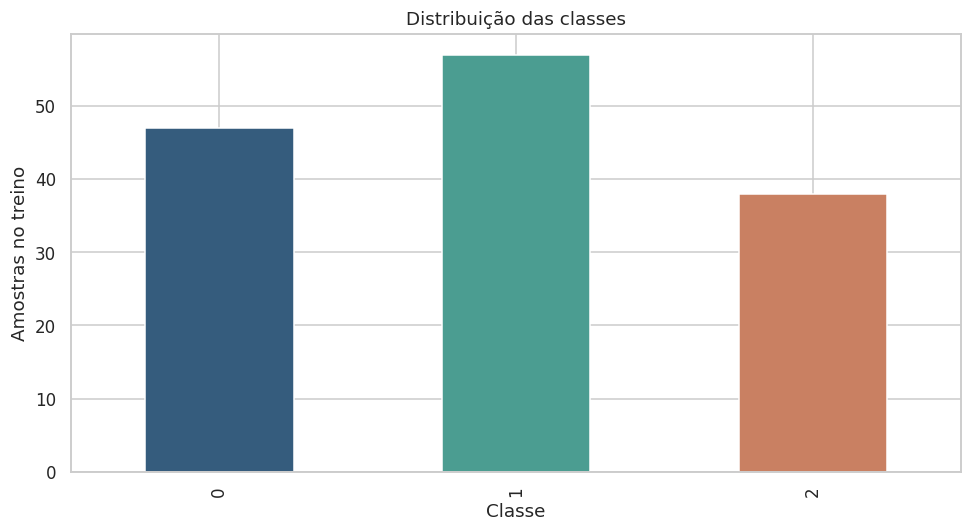

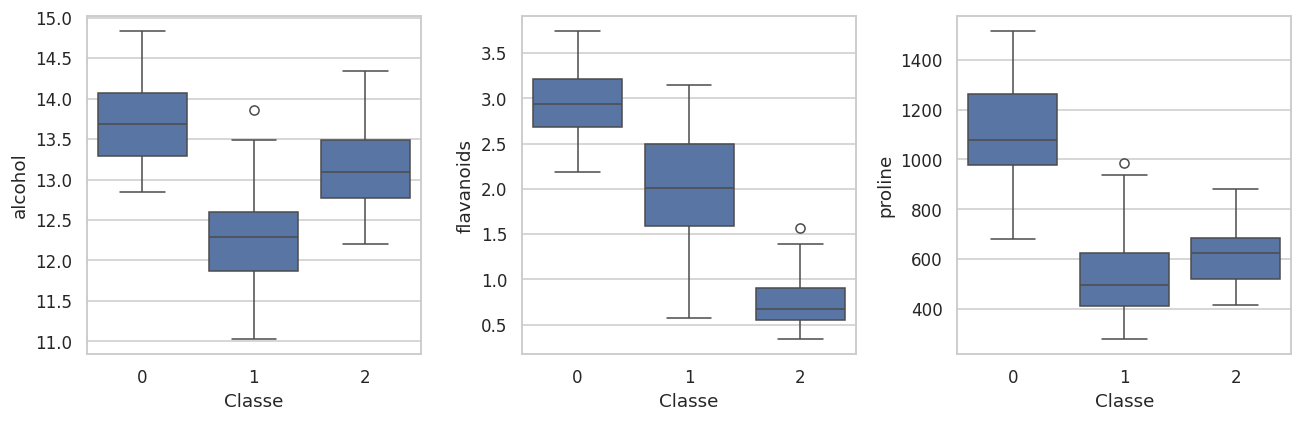

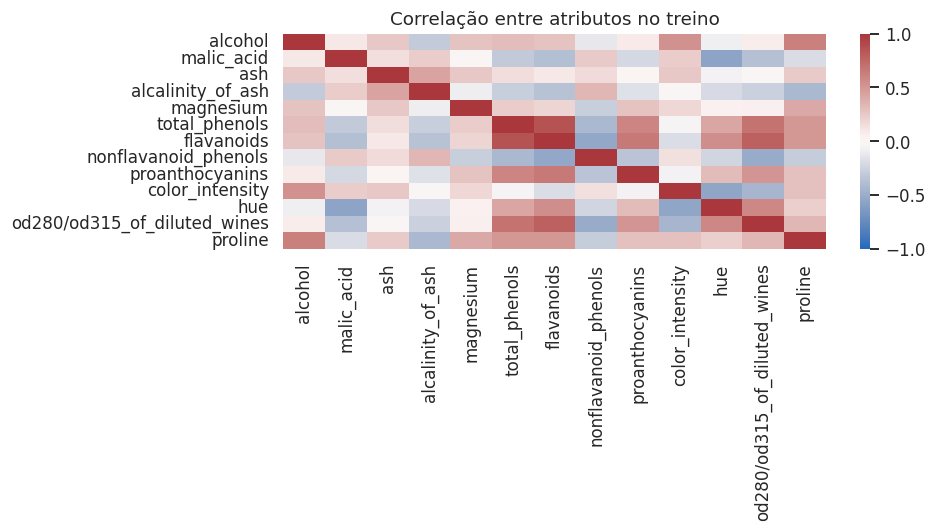

,alcohol,flavanoids,proline
target,,,
0,13.680,2.940,1080.0
1,12.290,2.010,495.0
2,13.095,0.675,622.5


**Leitura dos gráficos:** as classes não têm a mesma frequência, o que sustenta o F1 macro. Álcool, flavonoides e prolina apresentam distribuições diferentes entre classes, mas há sobreposição: um corte isolado não explica todas as amostras. A correlação entre medidas de compostos fenólicos indica redundância; mantemos as 13 variáveis para evitar seleção exploratória excessiva em uma base pequena. Correlação e importância não implicam causalidade.

In [4]:
train = X_train.assign(target=y_train)
def audit(frame):
    numeric = frame.select_dtypes(include='number')
    return pd.Series({'linhas': len(frame), 'colunas': frame.shape[1],
        'ausentes': int(frame.isna().sum().sum()),
        'duplicatas': int(frame.duplicated().sum()),
        'infinitos': int(np.isinf(numeric.to_numpy()).sum()),
        'medidas_nao_positivas': int((frame[features] <= 0).sum().sum())})
display(X_train.dtypes.to_frame('tipo'))
assert set(y_train.unique()) == {0, 1, 2}
before = audit(train)
assert before['infinitos'] == 0
assert before['duplicatas'] == 0
preview = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_train),
                       columns=features, index=X_train.index).assign(target=y_train)
audit_table = pd.DataFrame({'antes': before, 'depois': audit(preview)})
display(audit_table)
audit_table.to_csv('results/auditoria_treino.csv')
print('Nenhuma linha ou variável removida; 142 linhas de treino e 36 reservadas.')
y_train.value_counts().sort_index().plot.bar(color=['#355C7D','#4B9D91','#C98062'])
plt.xlabel('Classe'); plt.ylabel('Amostras no treino'); plt.title('Distribuição das classes')
figure('01_classes')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['alcohol', 'flavanoids', 'proline']):
    sns.boxplot(data=train, x='target', y=col, ax=ax)
    ax.set_xlabel('Classe')
figure('02_boxplots')
sns.heatmap(X_train.corr(), cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Correlação entre atributos no treino')
figure('03_correlacoes')
display(train.groupby('target')[['alcohol','flavanoids','proline']].median())
display(Markdown('**Leitura dos gráficos:** as classes não têm a mesma frequência, o que sustenta o F1 macro. Álcool, flavonoides e prolina apresentam distribuições diferentes entre classes, mas há sobreposição: um corte isolado não explica todas as amostras. A correlação entre medidas de compostos fenólicos indica redundância; mantemos as 13 variáveis para evitar seleção exploratória excessiva em uma base pequena. Correlação e importância não implicam causalidade.'))

<br>

---

<br>

### **Exercício 3 — Escolha de variáveis e desenho experimental — 1,0 ponto**

Defina formalmente o conjunto de variáveis utilizado na modelagem e estabeleça o protocolo experimental antes de treinar os algoritmos.

1. **Escolha das variáveis — 0,35 ponto.** Defina $\mathbf{X}$ e $\mathbf{y}$. Liste variáveis removidas e justifique a exclusão. Identificadores, informações disponíveis apenas depois do evento previsto e variáveis que revelem diretamente o alvo devem ser analisados como possíveis fontes de **data leakage**.
2. **Separação treino–teste e validação cruzada — 0,35 ponto.** Construa $\mathcal{D}_{\mathrm{treino}}$ e $\mathcal{D}_{\mathrm{teste}}$ com uma proporção adequada e `random_state` fixo. Em classificação, utilize estratificação quando aplicável. Defina o esquema de validação cruzada que será usado dentro de $\mathcal{D}_{\mathrm{treino}}$.
3. **Métricas — 0,30 ponto.** Registre a métrica principal e as métricas auxiliares. Explique por que elas são adequadas ao problema e como serão interpretadas.

**Referência de decisão:** para classificação, considere o balanceamento das classes ao escolher entre acurácia, precision, recall, F1, ROC-AUC ou outras métricas pertinentes. Para regressão, considere métricas como MAE, RMSE e $R^2$. A escolha deve ser justificada e mantida de forma consistente ao comparar os modelos.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Regra experimental:</strong> os três algoritmos devem utilizar o mesmo conjunto de teste e, sempre que possível, os mesmos folds de validação cruzada e a mesma métrica principal. O conjunto de teste não pode participar do Grid Search, do Optuna ou da escolha do melhor modelo.
</div>

### Resposta 3 — Protocolo fixado antes da modelagem
`X` contém todas as 13 medidas químicas disponíveis antes da classificação. `y` é `target`, excluído de X. O índice identifica linhas somente para auditoria e não entra no pipeline; não existem outras colunas de identificadores ou eventos posteriores. Não há exclusões orientadas por desempenho.

Separação estratificada 80/20, `random_state=42`: 142 amostras de treino e 36 de teste. Os mesmos três folds estratificados e embaralhados são materializados uma única vez para todos os modelos e buscas. Três folds conservam aproximadamente 95 amostras para cada ajuste e permitem 60 trials mais as grades com custo moderado. O teste não participa da exploração, tuning, curva de aprendizado ou escolha final.

Maximizamos F1 macro; também relatamos acurácia e precisão/recall macro. Log loss avalia as probabilidades (menor é melhor). O desvio dos três folds mede dispersão, não é um intervalo de confiança. O campeão é escolhido pelo maior F1 médio de CV; diferenças de até 0,005 são tratadas como empate prático e resolvidas por menor desvio e depois menor tempo médio de ajuste. Essa regra é definida aqui, antes dos resultados.

In [5]:
cv = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED).split(X_train, y_train))
assert set(X_train.index).isdisjoint(X_test.index)
splits = {'train': X_train.index.tolist(), 'test': X_test.index.tolist(),
          'cv': [{'train': a.tolist(), 'valid': b.tolist()} for a, b in cv]}
Path('results/splits.json').write_text(json.dumps(splits, indent=2))
dummy = cross_validate(DummyClassifier(strategy='most_frequent'), X_train, y_train,
                       cv=cv, scoring='f1_macro')
print('F1 macro da classe majoritária:', dummy['test_score'].mean())

F1 macro da classe majoritária: 0.1909643700688477


<br>

---

<br>

### **Exercício 4 — Implementação dos três modelos de referência — 1,5 ponto**

Implemente uma primeira versão comparável dos três algoritmos antes do tuning:

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

Utilize as classes de classificação ou regressão correspondentes ao problema escolhido.

1. **Random Forest — 0,30 ponto.** Treine um modelo de referência e registre os hiperparâmetros utilizados.
2. **XGBoost — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
3. **LightGBM — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
4. **Comparação inicial — 0,60 ponto.** Construa uma tabela única contendo, no mínimo, modelo, métrica no treino, média da validação cruzada, desvio-padrão da validação cruzada e tempo de treinamento. Interprete as diferenças observadas e identifique sinais iniciais de overfitting ou underfitting.

O objetivo desta etapa é criar um **baseline comparável**, não encontrar ainda o melhor conjunto de hiperparâmetros.

**Sugestões de gráficos:** barras com a média e dispersão dos scores de validação cruzada; comparação entre score de treino e score médio de validação; tempo de treinamento por modelo.

### Resposta 4 — Modelos de referência
Todos recebem o mesmo pipeline com mediana, mesmas variáveis e folds. O tempo de ajuste é a média dos ajustes de CV, separado do tempo total da estratégia. O score de treino também é a média nos subconjuntos de ajuste dos folds, permitindo comparação direta com a validação. Usamos uma única thread por estimador para evitar sobreposição de paralelismo e estabilizar os tempos. Os parâmetros completos são registrados em JSON, inclusive defaults da versão instalada.

Random Forest: treino=1.0000, CV=0.9525, gap=0.0475.
XGBoost: treino=1.0000, CV=0.9300, gap=0.0700.
LightGBM: treino=1.0000, CV=0.9512, gap=0.0488.
Treino superior à validação sugere sobreajuste; CV alta frente ao dummy não sustenta underfitting forte. A pequena base exige cautela com diferenças de poucos pontos.


,modelo,estrategia,f1_treino,f1_cv,desvio_cv,ajuste_medio_s,busca_s,gap
0,Random Forest,Baseline,1.0,0.9525,0.0508,0.0747,0,0.0475
1,XGBoost,Baseline,1.0,0.9300,0.0487,0.0194,0,0.0700
2,LightGBM,Baseline,1.0,0.9512,0.0257,0.0173,0,0.0488


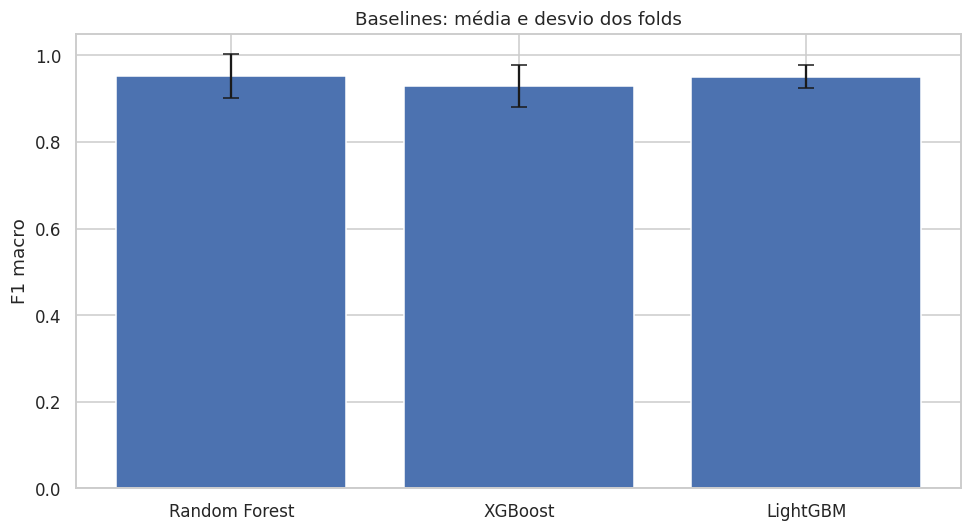

In [6]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        tree_method='hist', random_state=SEED, n_jobs=1),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=3, num_leaves=7,
        learning_rate=0.1, min_child_samples=10, verbosity=-1,
        deterministic=True, force_col_wise=True, random_state=SEED, n_jobs=1),
}
pipelines = {name: Pipeline([('imputer', SimpleImputer(strategy='median')),
                            ('model', model)]) for name, model in models.items()}
Path('results/parametros_baseline.json').write_text(json.dumps(
    {name: model.get_params() for name, model in models.items()}, indent=2))
rows, candidates = [], {}
def assess(name, strategy, pipeline, search_seconds=0):
    scores = cross_validate(pipeline, X_train, y_train, cv=cv,
        scoring='f1_macro', return_train_score=True, n_jobs=1)
    row = {'modelo': name, 'estrategia': strategy,
        'f1_treino': scores['train_score'].mean(), 'f1_cv': scores['test_score'].mean(),
        'desvio_cv': scores['test_score'].std(ddof=1),
        'ajuste_medio_s': scores['fit_time'].mean(), 'busca_s': search_seconds}
    row['gap'] = row['f1_treino'] - row['f1_cv']
    rows.append(row)
    candidates[(name, strategy)] = clone(pipeline)
    return row
for name, pipeline in pipelines.items():
    assess(name, 'Baseline', pipeline)
display(pd.DataFrame(rows).round(4))
base = pd.DataFrame(rows)
plt.bar(base.modelo, base.f1_cv, yerr=base.desvio_cv, capsize=5)
plt.ylim(0, 1.05); plt.ylabel('F1 macro'); plt.title('Baselines: média e desvio dos folds')
figure('04_baselines')
for r in rows:
    print(f"{r['modelo']}: treino={r['f1_treino']:.4f}, CV={r['f1_cv']:.4f}, gap={r['gap']:.4f}.")
print('Treino superior à validação sugere sobreajuste; CV alta frente ao dummy não sustenta underfitting forte. A pequena base exige cautela com diferenças de poucos pontos.')

**Análise dos resultados executados.** Random Forest foi o melhor baseline (F1 macro CV 0,9525), muito próximo de LightGBM (0,9512). XGBoost ficou em 0,9300. Todos atingiram F1 de treino 1,0000, com gaps de 0,0475, 0,0488 e 0,0700, respectivamente: há sinais de sobreajuste, sobretudo no XGBoost. O desvio do LightGBM (0,0257) foi menor que os aproximadamente 0,05 dos demais, mas três folds não sustentam uma conclusão estatística forte.

<br>

---

<br>

### **Exercício 5 — Tuning com Grid Search e Optuna — 2,0 pontos**

Ajuste os hiperparâmetros de **cada um dos três modelos** usando duas estratégias distintas: Grid Search e Optuna. Todo tuning deve ocorrer exclusivamente sobre $\mathcal{D}_{\mathrm{treino}}$ e utilizar o protocolo de validação definido no Exercício 3.

O problema geral pode ser representado como a busca por um conjunto de hiperparâmetros $\boldsymbol{\theta}$ que otimiza a métrica de validação cruzada:

$$
\boldsymbol{\theta}^{\star}
=
\operatorname*{arg\,opt}_{\boldsymbol{\theta}\in\Theta}
\frac{1}{K}
\sum_{k=1}^{K}
S_k(\boldsymbol{\theta}),
$$

em que $\operatorname*{arg\,opt}$ significa maximizar uma métrica de desempenho ou minimizar uma função de erro, conforme a métrica principal adotada.

1. **Grid Search — 0,75 ponto.** Para $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, defina uma grade coerente de hiperparâmetros, execute a busca e registre os melhores parâmetros, o score médio de validação e o custo computacional. A grade deve explorar parâmetros que controlem complexidade, número de árvores e/ou taxa de aprendizado, conforme o algoritmo.
2. **Optuna — 1,00 ponto.** Para os três modelos, defina uma função objetivo baseada na mesma métrica principal e nos mesmos dados de validação. Documente o espaço de busca, o número de trials e o melhor conjunto de hiperparâmetros. Como referência, utilize pelo menos 20 trials por modelo ou justifique claramente uma quantidade menor por restrição computacional.
3. **Comparação das estratégias — 0,25 ponto.** Compare Grid Search e Optuna em qualidade da solução, custo computacional e comportamento da busca. Não escolha uma estratégia apenas porque produziu um número ligeiramente melhor; discuta estabilidade e complexidade.

**Sugestões de gráficos:** curva ou mapa de scores do `cv_results_` do Grid Search para hiperparâmetros relevantes; histórico de otimização do Optuna; importância dos hiperparâmetros no Optuna; tempo de busca por modelo e estratégia.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Controle de comparabilidade:</strong> mantenha a métrica principal, a preparação dos dados e o esquema de validação tão consistentes quanto possível entre os três modelos. Se houver diferença de pipeline necessária por causa de uma biblioteca ou tipo de variável, explique a diferença e por que ela não invalida a comparação.
</div>

### Resposta 5 — Duas estratégias para cada algoritmo
Grid Search avalia 8 combinações por algoritmo (24 no total). As grades variam número de árvores e complexidade; nos boosters também variam taxa de aprendizado. Optuna usa TPE com semente fixa e **20 trials por modelo**, sem pruning, nos mesmos três folds e com o mesmo F1 macro. Os espaços incluem folhas mínimas/subamostragem, além de complexidade e taxa de aprendizado. O custo é diferente: 8 versus 20 configurações por algoritmo; isso será considerado na interpretação.

Os melhores parâmetros, resultados completos das grades e todos os trials são exportados. A dispersão dos folds ajuda a avaliar estabilidade, mas usamos apenas uma semente de busca: não alegamos estabilidade entre execuções com sementes diferentes. Reutilizar CV no tuning gera otimismo de seleção; o teste isolado será a avaliação final independente.

Random Forest: Optuna - Grid = +0.0000 F1; custos 5.14s e 2.49s.
XGBoost: Optuna - Grid = +0.0225 F1; custos 1.38s e 0.67s.
LightGBM: Optuna - Grid = +0.0076 F1; custos 0.92s e 0.50s.
Ganhos pequenos não comprovam superioridade estatística. Optuna explora mais combinações e um espaço maior; o histórico mostra se esse orçamento trouxe melhora ou apenas um platô.


,modelo,estrategia,f1_treino,f1_cv,desvio_cv,ajuste_medio_s,busca_s,gap
0,Random Forest,Baseline,1.0000,0.9525,0.0508,0.0747,0.0000,0.0475
1,XGBoost,Baseline,1.0000,0.9300,0.0487,0.0194,0.0000,0.0700
2,LightGBM,Baseline,1.0000,0.9512,0.0257,0.0173,0.0000,0.0488
3,Random Forest,Grid,0.9964,0.9525,0.0508,0.0611,2.4876,0.0440
4,XGBoost,Grid,1.0000,0.9300,0.0487,0.0170,0.6718,0.0700
5,LightGBM,Grid,1.0000,0.9589,0.0362,0.0180,0.4962,0.0411
6,Random Forest,Optuna,1.0000,0.9525,0.0508,0.0701,5.1429,0.0475
7,XGBoost,Optuna,1.0000,0.9525,0.0508,0.0310,1.3814,0.0475
8,LightGBM,Optuna,1.0000,0.9665,0.0243,0.0128,0.9153,0.0335


{'Random Forest / Grid': {'model__max_depth': 3,
  'model__min_samples_leaf': 1,
  'model__n_estimators': 80},
 'XGBoost / Grid': {'model__learning_rate': 0.1,
  'model__max_depth': 4,
  'model__n_estimators': 80},
 'LightGBM / Grid': {'model__learning_rate': 0.03,
  'model__n_estimators': 160,
  'model__num_leaves': 4},
 'Random Forest / Optuna': {'model__n_estimators': 100,
  'model__max_depth': None,
  'model__min_samples_leaf': 1,
  'model__max_features': 'sqrt'},
 'XGBoost / Optuna': {'model__n_estimators': 140,
  'model__learning_rate': 0.027575529238707534,
  'model__max_depth': 3,
  'model__min_child_weight': 2,
  'model__colsample_bytree': 0.8368209952651108},
 'LightGBM / Optuna': {'model__n_estimators': 100,
  'model__learning_rate': 0.1499992666483151,
  'model__num_leaves': 7,
  'model__min_child_samples': 6}}

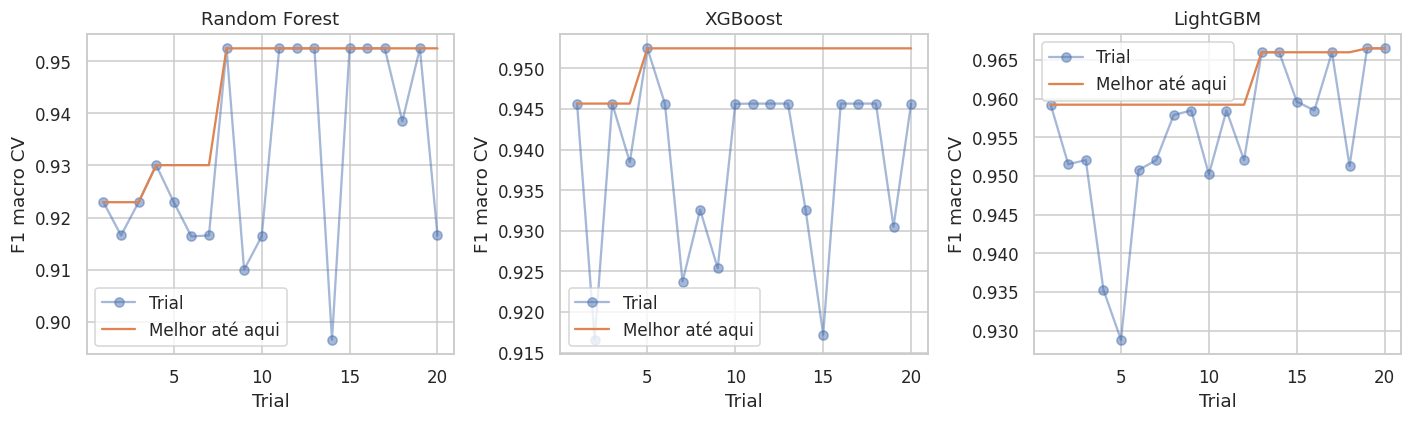

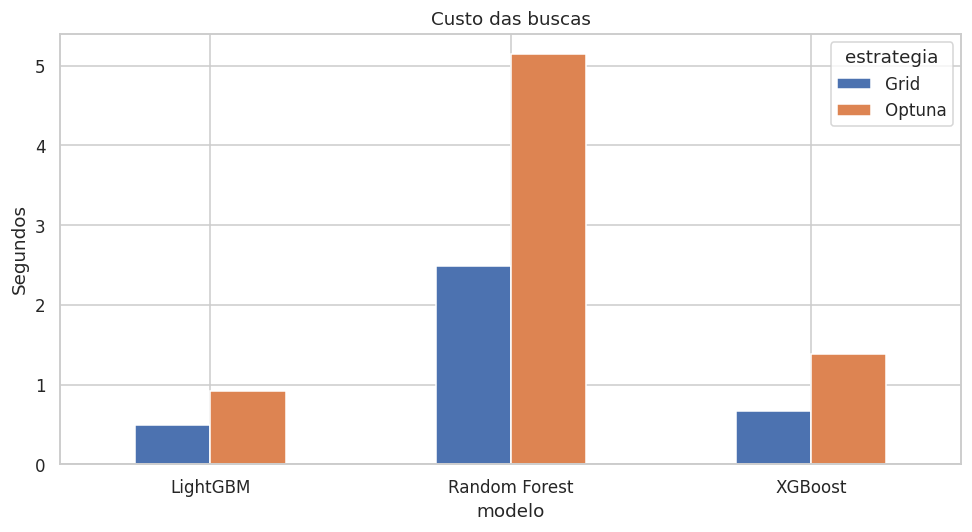

In [7]:
grids = {
    'Random Forest': {'model__n_estimators': [80, 160], 'model__max_depth': [3, None],
                      'model__min_samples_leaf': [1, 3]},
    'XGBoost': {'model__n_estimators': [80, 160], 'model__max_depth': [2, 4],
                'model__learning_rate': [0.03, 0.1]},
    'LightGBM': {'model__n_estimators': [80, 160], 'model__num_leaves': [4, 7],
                'model__learning_rate': [0.03, 0.1]},
}
Path('results/grades.json').write_text(json.dumps(grids, indent=2))
best_params, studies = {}, {}
for name, pipeline in pipelines.items():
    start = perf_counter()
    grid = GridSearchCV(pipeline, grids[name], cv=cv, scoring='f1_macro',
                        n_jobs=1, refit=False, return_train_score=True)
    grid.fit(X_train, y_train)
    elapsed = perf_counter() - start
    best_params[name + ' / Grid'] = grid.best_params_
    pd.DataFrame(grid.cv_results_).to_csv(f'results/grid_{name}.csv', index=False)
    assess(name, 'Grid', clone(pipeline).set_params(**grid.best_params_), elapsed)

def suggest(trial, name):
    p = {'model__n_estimators': trial.suggest_int('model__n_estimators', 60, 180, step=20)}
    if name == 'Random Forest':
        p.update({'model__max_depth': trial.suggest_categorical('model__max_depth', [3, 5, 8, None]),
            'model__min_samples_leaf': trial.suggest_int('model__min_samples_leaf', 1, 5),
            'model__max_features': trial.suggest_categorical('model__max_features', ['sqrt', 0.7, 1.0])})
    else:
        p['model__learning_rate'] = trial.suggest_float('model__learning_rate', 0.02, 0.2, log=True)
        if name == 'XGBoost':
            p.update({'model__max_depth': trial.suggest_int('model__max_depth', 2, 5),
                'model__min_child_weight': trial.suggest_int('model__min_child_weight', 1, 5),
                'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0)})
        else:
            p.update({'model__num_leaves': trial.suggest_int('model__num_leaves', 3, 7),
                'model__min_child_samples': trial.suggest_int('model__min_child_samples', 5, 20)})
    return p
for name, pipeline in pipelines.items():
    def objective(trial):
        candidate = clone(pipeline).set_params(**suggest(trial, name))
        score = cross_validate(candidate, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=1)
        trial.set_user_attr('desvio_cv', float(score['test_score'].std(ddof=1)))
        return float(score['test_score'].mean())
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    start = perf_counter()
    study.optimize(objective, n_trials=20)
    elapsed = perf_counter() - start
    studies[name] = study
    best_params[name + ' / Optuna'] = study.best_params
    study.trials_dataframe().to_csv(f'results/optuna_{name}.csv', index=False)
    assess(name, 'Optuna', clone(pipeline).set_params(**study.best_params), elapsed)
Path('results/melhores_parametros.json').write_text(json.dumps(best_params, indent=2))
display(pd.DataFrame(rows).round(4))
display(best_params)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, study) in zip(axes, studies.items()):
    vals = [t.value for t in study.trials]
    ax.plot(range(1, 21), vals, 'o-', alpha=0.5, label='Trial')
    ax.plot(range(1, 21), np.maximum.accumulate(vals), label='Melhor até aqui')
    ax.set(title=name, xlabel='Trial', ylabel='F1 macro CV'); ax.legend()
figure('05_optuna')
comparison = pd.DataFrame(rows)
comparison[comparison.estrategia != 'Baseline'].pivot(index='modelo', columns='estrategia', values='busca_s').plot.bar()
plt.ylabel('Segundos'); plt.title('Custo das buscas'); plt.xticks(rotation=0)
figure('06_tempos')
for name in models:
    a = comparison[(comparison.modelo == name) & (comparison.estrategia == 'Grid')].iloc[0]
    b = comparison[(comparison.modelo == name) & (comparison.estrategia == 'Optuna')].iloc[0]
    print(f"{name}: Optuna - Grid = {b.f1_cv-a.f1_cv:+.4f} F1; custos {b.busca_s:.2f}s e {a.busca_s:.2f}s.")
print('Ganhos pequenos não comprovam superioridade estatística. Optuna explora mais combinações e um espaço maior; o histórico mostra se esse orçamento trouxe melhora ou apenas um platô.')

**Comparação concreta das buscas.** No Random Forest, Grid e Optuna empataram em 0,9525; a grade levou aproximadamente 2,49 s e Optuna 5,14 s, sem benefício de score. No XGBoost, Optuna elevou F1 de 0,9300 para 0,9525, ao custo de 1,38 s contra 0,67 s. No LightGBM, passou de 0,9589 (Grid) para 0,9665 (Optuna), e o desvio entre folds caiu de 0,0362 para 0,0243; os custos foram 0,50 s e 0,92 s. Tempos são desta máquina e não generalizam a bases grandes. O ganho do LightGBM é pequeno frente à dispersão; a escolha aplica o protocolo, não prova superioridade estatística. Os históricos mostram o melhor score acumulado e os trials que não melhoram o resultado.

<br>

---

<br>

### **Exercício 6 — Escolha do melhor modelo e análise de overfitting/underfitting — 1,5 ponto**

Com base apenas nos resultados de treinamento e validação cruzada, escolha a configuração que será promovida a modelo final. A escolha deve considerar desempenho, variabilidade entre folds, diferença entre treino e validação, custo e complexidade.

1. **Seleção do modelo — 0,50 ponto.** Construa uma tabela final com, no mínimo, as nove configurações principais: baseline, melhor Grid Search e melhor Optuna para cada um dos três algoritmos. Defina qual configuração será levada ao teste final e justifique a decisão.
2. **Overfitting e underfitting — 0,50 ponto.** Compare desempenho de treino e validação e produza uma **curva de aprendizado** para a configuração escolhida. Discuta se há evidências de overfitting, underfitting ou comportamento compatível com boa generalização.
3. **Interpretação do comportamento do modelo — 0,50 ponto.** Produza um gráfico de importância das variáveis para o modelo escolhido e pelo menos um gráfico de desempenho adequado ao tipo de problema:
   - **classificação:** matriz de confusão e, quando pertinente, curva ROC ou Precision–Recall;
   - **regressão:** valores observados versus previstos e/ou análise de resíduos.

Para uma métrica em que valores maiores representam melhor desempenho, um indício simples de sobreajuste pode ser observado pelo gap

$$
\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}.
$$

Para uma função de erro em que valores menores são melhores, considere

$$
\Delta_{\downarrow}=L_{\mathrm{CV}}-L_{\mathrm{treino}}.
$$

Um gap elevado pode indicar sobreajuste, mas a conclusão deve considerar também a curva de aprendizado, a variabilidade dos folds e a escala da métrica.

### Resposta 6 — Seleção e generalização
Aplicamos a regra fixada no exercício 3 às nove configurações. Não consultamos o teste. A curva de aprendizado refaz ajustes em frações crescentes do treino sob os mesmos folds; a matriz de confusão desta etapa usa previsões out-of-fold do treino. A importância é a redução de impureza/ganho nativa do estimador escolhido, normalizada para soma 1, não uma medida causal. Atributos correlacionados podem dividir essa importância. OOF do campeão ainda sofre influência da seleção nos mesmos folds; somente a etapa 7 estima o desempenho no teste isolado.

Selecionado antes do teste: LightGBM / Optuna
F1 CV=0.9665; desvio=0.0243; gap=0.0335
Curva: validação vai de 0.9146 a 0.9665.
A distância treino-validação e a dispersão devem ser lidas juntas; validação alta não elimina sobreajuste. Mais dados independentes são necessários para generalizar além desta base.
Três maiores importâncias: color_intensity, flavanoids, proline


,modelo,estrategia,f1_treino,f1_cv,desvio_cv,ajuste_medio_s,busca_s,gap
8,LightGBM,Optuna,1.0000,0.9665,0.0243,0.0128,0.9153,0.0335
5,LightGBM,Grid,1.0000,0.9589,0.0362,0.0180,0.4962,0.0411
0,Random Forest,Baseline,1.0000,0.9525,0.0508,0.0747,0.0000,0.0475
3,Random Forest,Grid,0.9964,0.9525,0.0508,0.0611,2.4876,0.0440
6,Random Forest,Optuna,1.0000,0.9525,0.0508,0.0701,5.1429,0.0475
7,XGBoost,Optuna,1.0000,0.9525,0.0508,0.0310,1.3814,0.0475
2,LightGBM,Baseline,1.0000,0.9512,0.0257,0.0173,0.0000,0.0488
4,XGBoost,Grid,1.0000,0.9300,0.0487,0.0170,0.6718,0.0700
1,XGBoost,Baseline,1.0000,0.9300,0.0487,0.0194,0.0000,0.0700


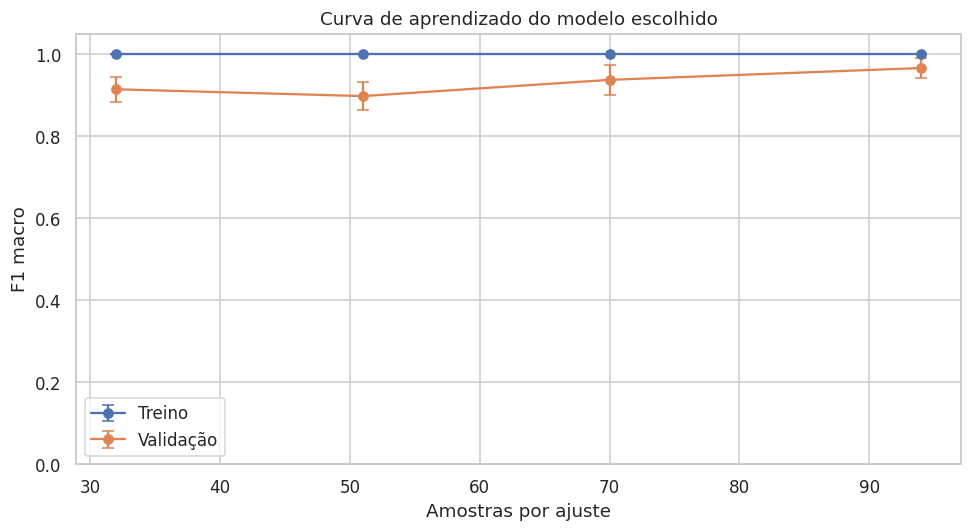

,n,treino,validacao,desvio
0,32,1.0,0.914608,0.031183
1,51,1.0,0.898037,0.034184
2,70,1.0,0.937665,0.037282
3,94,1.0,0.966513,0.024339


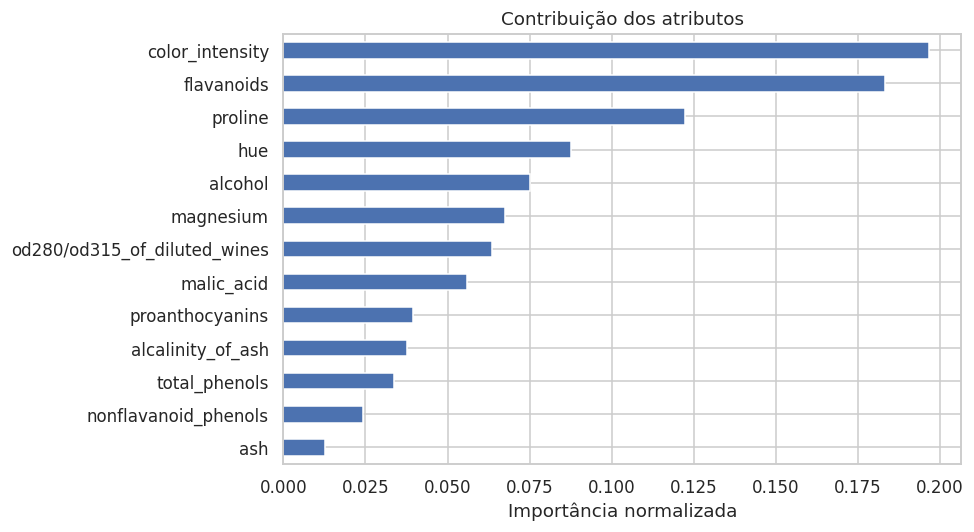

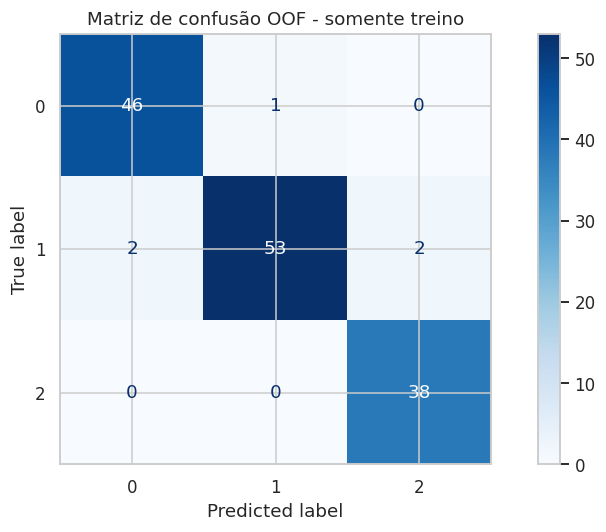

In [8]:
table = pd.DataFrame(rows)
eligible = table[table.f1_cv >= table.f1_cv.max() - 0.005]
winner = eligible.sort_values(['desvio_cv', 'ajuste_medio_s', 'modelo', 'estrategia']).iloc[0]
selected = clone(candidates[(winner.modelo, winner.estrategia)])
table.to_csv('results/comparacao.csv', index=False)
display(table.sort_values('f1_cv', ascending=False).round(4))
print('Selecionado antes do teste:', winner.modelo, '/', winner.estrategia)
print(f"F1 CV={winner.f1_cv:.4f}; desvio={winner.desvio_cv:.4f}; gap={winner.gap:.4f}")
sizes, train_scores, valid_scores = learning_curve(selected, X_train, y_train,
    cv=cv, train_sizes=[0.35, 0.55, 0.75, 1.0], scoring='f1_macro', shuffle=True,
    random_state=SEED, n_jobs=1)
for scores, label in [(train_scores, 'Treino'), (valid_scores, 'Validação')]:
    plt.errorbar(sizes, scores.mean(axis=1), yerr=scores.std(axis=1, ddof=1),
                 marker='o', capsize=4, label=label)
plt.xlabel('Amostras por ajuste'); plt.ylabel('F1 macro'); plt.ylim(0, 1.05)
plt.title('Curva de aprendizado do modelo escolhido'); plt.legend()
figure('07_aprendizado')
learning = pd.DataFrame({'n': sizes, 'treino': train_scores.mean(axis=1),
    'validacao': valid_scores.mean(axis=1), 'desvio': valid_scores.std(axis=1, ddof=1)})
learning.to_csv('results/aprendizado.csv', index=False)
display(learning)
interpret_model = clone(selected).fit(X_train, y_train)
importance = interpret_model.named_steps['model'].feature_importances_.astype(float)
importance = pd.Series(importance / importance.sum(), index=features).sort_values()
importance.to_csv('results/importancias.csv', header=['importancia'])
importance.plot.barh(); plt.xlabel('Importância normalizada'); plt.title('Contribuição dos atributos')
figure('08_importancia')
oof = cross_val_predict(selected, X_train, y_train, cv=cv, method='predict', n_jobs=1)
ConfusionMatrixDisplay.from_predictions(y_train, oof, cmap='Blues')
plt.title('Matriz de confusão OOF - somente treino')
figure('09_confusao_oof')
print(f"Curva: validação vai de {learning.validacao.iloc[0]:.4f} a {learning.validacao.iloc[-1]:.4f}.")
print('A distância treino-validação e a dispersão devem ser lidas juntas; validação alta não elimina sobreajuste. Mais dados independentes são necessários para generalizar além desta base.')
print('Três maiores importâncias:', ', '.join(importance.tail(3).index[::-1]))

**Decisão e interpretação.** LightGBM/Optuna é o único candidato dentro de 0,005 do melhor score: F1 CV 0,9665, desvio 0,0243 e gap 0,0335. Foi escolhido antes de qualquer avaliação no teste. A curva mantém treino 1,0000 e validação entre 0,8980 e 0,9665; não é monotônica na menor faixa, como esperado com subamostras pequenas. No último ponto, mais dados reduzem o gap, sugerindo variância residual e benefício potencial de ampliar a amostra. Não há evidência de underfitting forte, pois o treino é perfeito e a validação supera amplamente o dummy. Não interpretamos isso como ausência de sobreajuste.

<br>

---

<br>

### **Exercício 7 — Teste final, consistência do modelo, entrega em produção e apresentação — 1,5 ponto**

Somente agora utilize $\mathcal{D}_{\mathrm{teste}}$. Refaça o treinamento da configuração selecionada usando todo $\mathcal{D}_{\mathrm{treino}}$ e execute a avaliação final uma única vez no conjunto de teste.

1. **Avaliação final — 0,50 ponto.** Calcule a métrica principal e as métricas auxiliares em $\mathcal{D}_{\mathrm{teste}}$. Compare o resultado de teste com a validação cruzada. Discuta se o desempenho final é compatível com o que era esperado durante o desenvolvimento.
2. **Teste de consistência — 0,40 ponto.** Selecione pelo menos cinco observações que não participaram do treinamento. Para cada uma, apresente as principais entradas, o valor real $y$, a previsão $\hat{y}$ e:
   - em classificação, a probabilidade prevista quando o estimador oferecer `predict_proba`;
   - em regressão, o erro individual $e_i=y_i-\hat{y}_i$.

   Interprete os casos e verifique se o comportamento do modelo é coerente com o padrão aprendido. Inclua pelo menos um caso em que o modelo acerta bem e um caso mais difícil, quando isso existir nos dados.
3. **GitHub e Streamlit — 0,60 ponto.** Disponibilize o projeto em um repositório GitHub e construa uma aplicação Streamlit que utilize **a mesma preparação de dados e o mesmo modelo final**. A interface deve receber as variáveis necessárias, gerar a previsão e apresentar o resultado de forma legível. O repositório deve conter, no mínimo:
   - `README.md` com descrição do problema, instruções de instalação e execução, links e resumo dos resultados;
   - notebook do CheckPoint05;
   - código da aplicação Streamlit;
   - arquivo de dependências (`requirements.txt` ou equivalente);
   - artefato do pipeline/modelo final ou código reproduzível para gerá-lo;
   - instruções para obtenção da base, caso ela não possa ser versionada no repositório.

Registre abaixo os links finais:

- **GitHub:** inserir URL do repositório.
- **Streamlit:** inserir URL da aplicação.

4. **Apresentação da solução — requisito obrigatório.** O grupo deverá realizar uma apresentação oral de **no máximo 10 minutos**. A exposição deve ser objetiva e demonstrar domínio sobre o desenvolvimento realizado. Organize a apresentação para contemplar, no mínimo:
   - problema escolhido, contexto, base de dados e variável-alvo;
   - principais decisões de data wrangling e escolha das variáveis;
   - comparação entre Random Forest, XGBoost e LightGBM;
   - resultados do Grid Search e do Optuna e justificativa da configuração final;
   - análise de overfitting e underfitting;
   - desempenho no conjunto de teste e principais conclusões sobre generalização;
   - demonstração breve da aplicação Streamlit e do teste de paridade entre notebook e interface.

A apresentação poderá utilizar slides ou a demonstração direta do projeto, desde que o tempo máximo seja respeitado. Todos os integrantes devem estar preparados para responder a perguntas sobre a solução desenvolvida.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Teste adicional de paridade:</strong> escolha pelo menos uma das observações do teste de consistência, reproduza os mesmos valores de entrada na aplicação Streamlit e verifique se a previsão exibida pela interface coincide com a previsão produzida pelo pipeline no notebook. Divergências devem ser investigadas antes da entrega.
</div>

### Resposta 7 — Teste reservado, consistência e aplicação
Refazemos o ajuste da configuração previamente escolhida em todo o treino e calculamos as previsões do teste uma única vez. Todas as métricas, gráficos e casos abaixo reutilizam essas previsões, sem escolher outro modelo após observar o teste. O modelo publicado como artefato conserva esse ajuste, sem incluir o teste no treinamento.

O teste de consistência usa cinco amostras do teste: prioriza até dois erros, se existirem, e completa com acertos de confiança alta e baixa. Essa seleção é apenas ilustrativa e posterior à avaliação global. Probabilidade alta não garante acerto, e não aplicamos calibração. A paridade compara o artefato recarregado, a função compartilhada pelo app e as previsões já calculadas; há também teste automatizado da interface Streamlit no projeto.

**GitHub e Streamlit público:** publicação pendente. O código, artefato e instruções estão incluídos; nenhum endereço de deploy foi inventado. Antes da submissão acadêmica, publicar e registrar os dois links finais em `links.json`.

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        12
           1     1.0000    1.0000    1.0000        14
           2     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        36
   macro avg     1.0000    1.0000    1.0000        36
weighted avg     1.0000    1.0000    1.0000        36

F1 teste - CV: +0.0335
Erros no teste: 0 / 36. Casos difíceis não são removidos.
GitHub: Publicação pendente
Streamlit: Publicação pendente
A amostra de teste é pequena. A concordância com CV deve ser interpretada com a dispersão, e não como garantia para novas safras.


,teste
f1_macro,1.00000
accuracy,1.00000
precision_macro,1.00000
recall_macro,1.00000
log_loss,0.00521


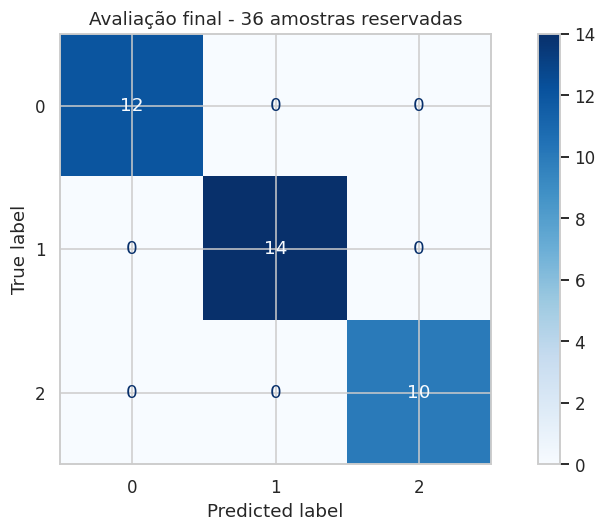

,alcohol,flavanoids,proline,y_real,y_previsto,confianca
121,11.56,5.08,465.0,1,1,0.901738
108,12.22,2.04,312.0,1,1,0.999999
66,13.11,3.18,502.0,1,1,0.923289
62,13.67,1.79,630.0,1,1,0.998025
130,12.86,1.25,630.0,2,2,0.998289


,id_amostra,classe,paridade
0,121,1,True
1,108,1,True
2,66,1,True
3,62,1,True
4,130,2,True


In [9]:
final_model = clone(selected).fit(X_train, y_train)
prob = final_model.predict_proba(X_test)
classes = final_model.classes_
pred = classes[np.argmax(prob, axis=1)]
metrics = {'f1_macro': f1_score(y_test, pred, average='macro'),
    'accuracy': accuracy_score(y_test, pred),
    'precision_macro': precision_score(y_test, pred, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test, pred, average='macro', zero_division=0),
    'log_loss': log_loss(y_test, prob, labels=classes)}
display(pd.Series(metrics, name='teste').to_frame())
print(classification_report(y_test, pred, digits=4))
print(f"F1 teste - CV: {metrics['f1_macro'] - winner.f1_cv:+.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap='Blues')
plt.title('Avaliação final - 36 amostras reservadas')
figure('10_confusao_teste')
all_test = X_test.copy()
all_test['y_real'] = y_test
all_test['y_previsto'] = pred
all_test['confianca'] = prob.max(axis=1)
for i, cls in enumerate(classes):
    all_test[f'p_classe_{cls}'] = prob[:, i]
all_test.to_csv('results/previsoes_teste.csv', index_label='id_amostra')
errors = all_test[all_test.y_real != all_test.y_previsto].sort_values('confianca', ascending=False)
correct = all_test[all_test.y_real == all_test.y_previsto].sort_values('confianca')
ids = list(errors.index[:2])
if len(correct):
    ids += [correct.index[0], correct.index[-1]]
ids = list(dict.fromkeys(ids + correct.index.tolist() + all_test.index.tolist()))[:5]
consistency = all_test.loc[ids]
consistency.to_csv('results/consistencia.csv', index_label='id_amostra')
display(consistency[['alcohol','flavanoids','proline','y_real','y_previsto','confianca']])
print(f'Erros no teste: {len(errors)} / {len(all_test)}. Casos difíceis não são removidos.')
joblib.dump(final_model, 'artifacts/pipeline.joblib')
metadata = {'features': features, 'labels_pt': labels_pt, 'classes': classes.tolist(),
    'defaults': X_train.median().to_dict(), 'ranges': {c: [float(X_train[c].min()), float(X_train[c].max())] for c in features},
    'modelo': winner.modelo, 'estrategia': winner.estrategia,
    'cv_f1': float(winner.f1_cv), 'cv_std': float(winner.desvio_cv),
    'gap': float(winner.gap), 'test_metrics': metrics,
    'integrantes': integrantes}
Path('artifacts/metadata.json').write_text(json.dumps(metadata, ensure_ascii=False, indent=2))
from inference import predict_sample
loaded = joblib.load('artifacts/pipeline.joblib')
parity = []
for idx in ids:
    label, probs = predict_sample(loaded, features, X_test.loc[idx].to_dict())
    pos = X_test.index.get_loc(idx)
    assert label == int(pred[pos])
    np.testing.assert_allclose(probs, prob[pos], rtol=1e-12, atol=1e-12)
    parity.append({'id_amostra': int(idx), 'classe': label, 'paridade': True})
display(pd.DataFrame(parity))
Path('results/paridade_funcao.json').write_text(json.dumps(parity, indent=2))
links = json.loads(Path('links.json').read_text())
print('GitHub:', links['github'] or 'Publicação pendente')
print('Streamlit:', links['streamlit'] or 'Publicação pendente')
print('A amostra de teste é pequena. A concordância com CV deve ser interpretada com a dispersão, e não como garantia para novas safras.')

**Conclusão do teste final.** O modelo acertou 36 de 36 amostras: F1 macro, acurácia, precisão macro e recall macro = 1,0000; log loss = 0,00521. O F1 ficou 0,0335 acima da média de CV. Esse resultado favorável não é uma garantia de acerto futuro: são apenas 36 observações da mesma origem, e a seleção reutilizou folds. Como referência descritiva, o intervalo de Wilson de 95% da acurácia para 36/36 é aproximadamente [0,904; 1,000], sob hipótese de observações independentes.

**Consistência.** Não houve erro no teste para ilustrar; a amostra 121 foi o acerto menos confiante (classe 1, probabilidade 0,9017). Seus flavonoides (5,08) excedem o máximo do treino (3,74), o que torna o exemplo útil para discutir extrapolação e o aviso da interface. A amostra 108 foi um acerto de confiança alta (classe 1, aproximadamente 0,9999994). As amostras 66, 62 e 130 completam os cinco casos. Todas as entradas e probabilidades das três classes estão no CSV. O artefato recarregado reproduziu os cinco resultados. O teste automatizado da interface está em `tests/test_app.py` e o registro em `results/paridade_interface.json`.

<br>

---

<br>

# **Referências**

* BREIMAN, Leo. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.

* CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: A Scalable Tree Boosting System. In: *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016.

* KE, Guolin et al. LightGBM: A Highly Efficient Gradient Boosting Decision Tree. In: *Advances in Neural Information Processing Systems*, 2017.

* AKIBA, Takuya et al. Optuna: A Next-generation Hyperparameter Optimization Framework. In: *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2019.

* GÉRON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 3. ed. Sebastopol: O'Reilly Media, 2023.

* KUHN, Max; JOHNSON, Kjell. *Feature Engineering and Selection: A Practical Approach for Predictive Models*. Boca Raton: CRC Press, 2020.

<br>

---

<br>

© 2026 Jones Egydio. Todos os direitos reservados.  

Conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/jones-egydio-msc-3300359/).